# rbp-binding — Exploratory Data Analysis

**Goal:** stress-test every modelling assumption *before* we train anything, and check whether
anything in the data defies the plan.

- **Panel:** 16 RNA-binding proteins (ENCODE eCLIP reproducible peaks).
- **Windows:** 101-nt, centred on each peak, strand-corrected. One GC-matched negative per positive.
- **Split (teammate standard):** `test = {chr1, chr2, chr20}`, `val = {chr19, chr16, chr13, chr18}`, rest `train`.

> This notebook reads the frozen `data/processed/` if present, otherwise previews on the existing
> windows (identical sequence content — extraction is deterministic; only the split label changes).


In [1]:
%matplotlib inline
import gzip
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

REPO = Path.cwd().parent
FROZEN, PREVIEW = REPO / "data/processed", REPO.parent / "rbp-v2/data/processed"
PROC = FROZEN if any(FROZEN.glob("*/dataset.tsv")) else PREVIEW
ENC  = REPO / "data/raw/encode"
print("reading windows from:", PROC, "(preview)" if PROC == PREVIEW else "(frozen)")

TEST_CHR, VAL_CHR = {"chr1","chr2","chr20"}, {"chr19","chr16","chr13","chr18"}
MIN_EVAL_PAIRS = 100
KNOWN = {"TARDBP":"UGUGUG","FUS":"GGUG","RBFOX2":"UGCAUG","PUM2":"UGUAUA","PUM1":"UGUAUA",
         "IGF2BP1":"ACACAC","TIA1":"UUUUU","PTBP1":"UCUCU","QKI":"ACUAAC"}

INK,MUTED,GRID,SURF = "#0b0b0b","#898781","#e1e0d9","#fcfcfb"
BLUE,ORANGE,GREEN,PURPLE,GOLD,GREY = "#2a78d6","#eb6834","#1baf7a","#8a5cf6","#e0b020","#9aa0a6"
mpl.rcParams.update({"figure.facecolor":SURF,"axes.facecolor":SURF,"savefig.facecolor":SURF,
    "axes.edgecolor":"#c3c2b7","xtick.color":MUTED,"ytick.color":MUTED,"axes.grid":True,
    "grid.color":GRID,"grid.linewidth":0.8,"axes.spines.top":False,"axes.spines.right":False,
    "font.size":9,"text.color":INK,"axes.labelcolor":"#52514e"})

def split_of(c): return "test" if c in TEST_CHR else "val" if c in VAL_CHR else "train"
def kmers(seqs,k=6):
    c=Counter()
    for s in seqs:
        for i in range(len(s)-k+1): c[s[i:i+k]]+=1
    return c
def low_complexity_frac(seqs):
    lc=0
    for s in seqs:
        n=len(s); top=max(s.count(b) for b in "ACGU")/n; run=mx=1
        for i in range(1,n):
            run=run+1 if s[i]==s[i-1] else 1; mx=max(mx,run)
        if top>0.60 or mx>=8: lc+=1
    return lc/max(len(seqs),1)

reg = pd.read_csv(REPO/"config/proteins.tsv", sep="\t")
proteins, acc = list(reg.protein), dict(zip(reg.protein, reg.accession))
data = {p: pd.read_csv(PROC/p/"dataset.tsv", sep="\t") for p in proteins}
for p in proteins: data[p]["split2"] = data[p].chrom.map(split_of)
print(len(proteins), "proteins,", sum(len(d) for d in data.values()), "windows")

reading windows from: /Users/nirmalkumar/Deep Learning Project/rbp-v2/data/processed (preview)


16 proteins, 157706 windows


## 1 · Dataset size & class balance
How many matched pairs per protein, and is every protein 1:1 balanced by construction?

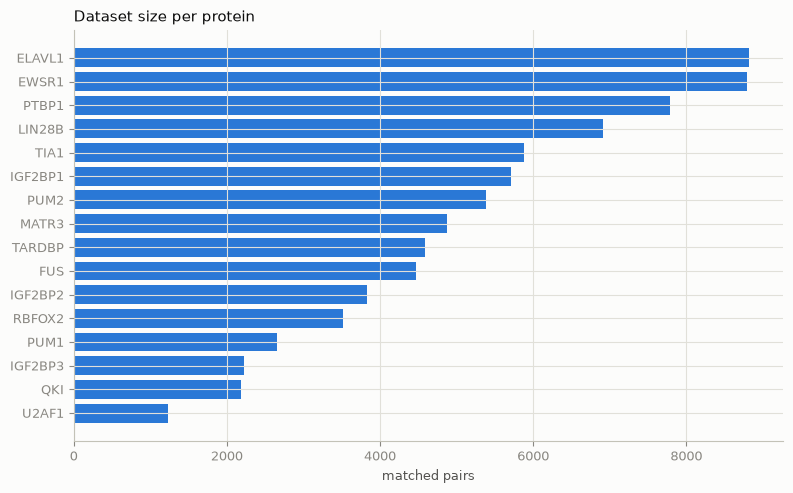

class balance (pos==neg for all): True
smallest: U2AF1 1230 pairs


In [2]:
sizes = {p:(int((data[p].label==1).sum()), int((data[p].label==0).sum())) for p in proteins}
S0 = pd.DataFrame({"protein":proteins,
                   "pos":[sizes[p][0] for p in proteins],
                   "neg":[sizes[p][1] for p in proteins]}).sort_values("pos")
fig,ax=plt.subplots(figsize=(8,5))
ax.barh(S0.protein, S0.pos, color=BLUE)
ax.set_xlabel("matched pairs"); ax.set_title("Dataset size per protein", loc="left")
plt.tight_layout(); plt.show()
print("class balance (pos==neg for all):", all(a==b for a,b in sizes.values()))
print("smallest:", S0.protein.iloc[0], int(S0.pos.iloc[0]), "pairs")

## 2 · Split balance — the decisive check
The whole point of the new split is a balanced, leakage-safe partition. Does every protein still
have enough pairs in **val** and **test**? Dashed line = 100-pair floor below which a split is too
small to trust.

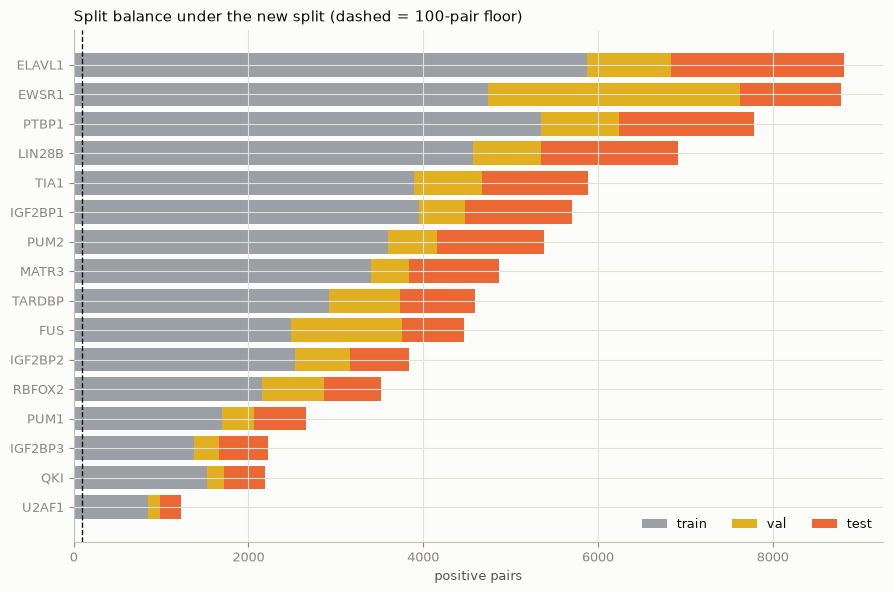

overall  train/val/test = 50927/12203/15723  (64.6/15.5/19.9 %)
thin (but above floor): ['U2AF1 val=133 test=247', 'QKI val=187 test=473']


In [3]:
sc = {p:{s:int((data[p][data[p].label==1].split2==s).sum()) for s in ("train","val","test")}
      for p in proteins}
order = sorted(proteins, key=lambda p: sizes[p][0])
fig,ax=plt.subplots(figsize=(9,6)); left=np.zeros(len(order))
for s,c in [("train",GREY),("val",GOLD),("test",ORANGE)]:
    v=np.array([sc[p][s] for p in order]); ax.barh(order,v,left=left,color=c,label=s); left+=v
ax.axvline(MIN_EVAL_PAIRS,color=INK,lw=1,ls="--")
ax.set_xlabel("positive pairs"); ax.legend(frameon=False,ncol=3)
ax.set_title("Split balance under the new split (dashed = 100-pair floor)",loc="left")
plt.tight_layout(); plt.show()

tot=pd.DataFrame(sc).T.sum()
print(f"overall  train/val/test = {tot.train}/{tot.val}/{tot.test}  "
      f"({tot.train/tot.sum()*100:.1f}/{tot.val/tot.sum()*100:.1f}/{tot.test/tot.sum()*100:.1f} %)")
thin=[(p,sc[p]['val'],sc[p]['test']) for p in proteins if sc[p]['val']<200 or sc[p]['test']<200]
print("thin (but above floor):", [f"{p} val={v} test={t}" for p,v,t in sorted(thin,key=lambda x:x[1])])

## 3 · Chromosome distribution
Where do each protein's positives fall? The test (orange) and val (gold) chromosomes are boxed.
Note **chr19** (in val) is the most gene-dense chromosome — it inflates val for some proteins.

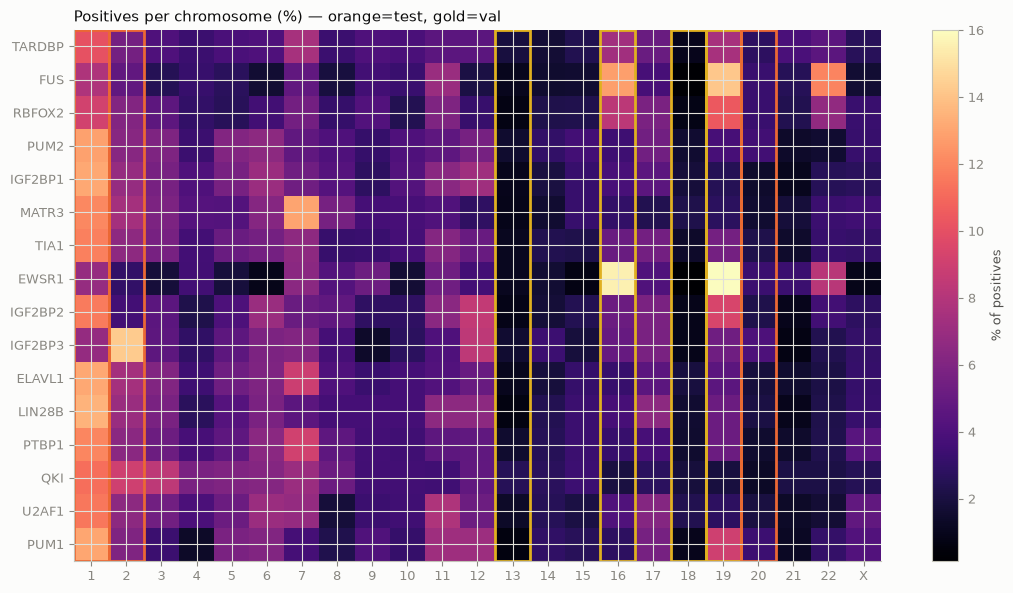

In [4]:
chroms=[f"chr{i}" for i in range(1,23)]+["chrX"]
M=np.zeros((len(proteins),len(chroms)))
for r,p in enumerate(proteins):
    vc=data[p][data[p].label==1].chrom.value_counts(normalize=True)
    for ci,c in enumerate(chroms): M[r,ci]=vc.get(c,0)*100
fig,ax=plt.subplots(figsize=(11,6))
im=ax.imshow(M,aspect="auto",cmap="magma")
ax.set_xticks(range(len(chroms))); ax.set_xticklabels([c.replace("chr","") for c in chroms])
ax.set_yticks(range(len(proteins))); ax.set_yticklabels(proteins)
for ci,c in enumerate(chroms):
    col=ORANGE if c in TEST_CHR else GOLD if c in VAL_CHR else None
    if col: ax.add_patch(plt.Rectangle((ci-.5,-.5),1,len(proteins),fill=False,edgecolor=col,lw=2))
ax.set_title("Positives per chromosome (%) — orange=test, gold=val",loc="left")
fig.colorbar(im,ax=ax,label="% of positives"); plt.tight_layout(); plt.show()

## 4 · GC matching
Negatives are drawn to match each positive's GC (±5%). If matching worked, the positive and
negative GC clouds sit on top of each other — so the model can't win on GC alone.

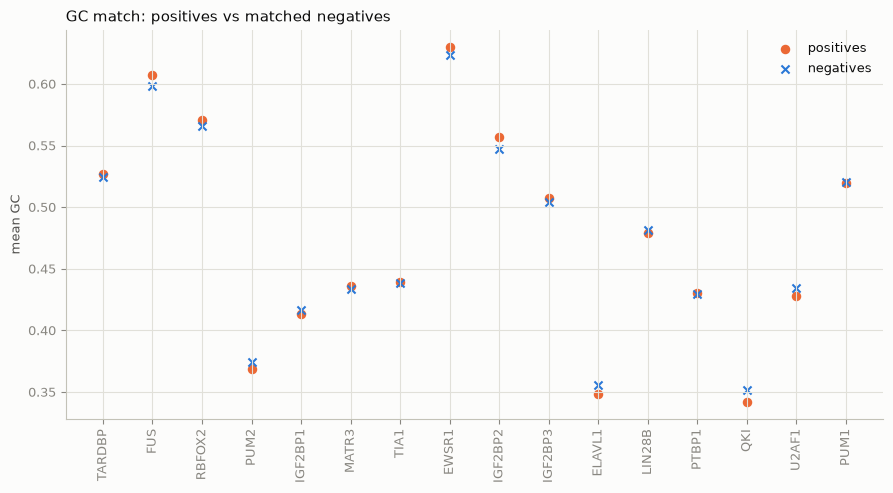

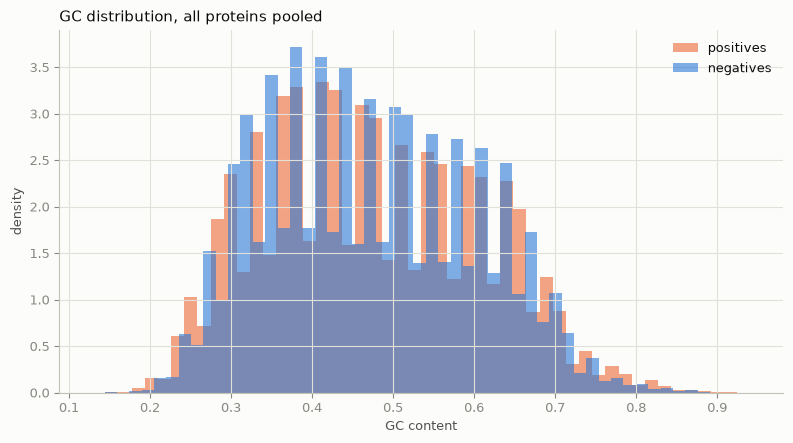

max mean-GC gap: 0.01


In [5]:
gp=[data[p][data[p].label==1].gc.mean() for p in proteins]
gn=[data[p][data[p].label==0].gc.mean() for p in proteins]
x=np.arange(len(proteins))
fig,ax=plt.subplots(figsize=(9,5))
ax.scatter(x,gp,s=34,color=ORANGE,label="positives"); ax.scatter(x,gn,s=34,color=BLUE,marker="x",label="negatives")
ax.set_xticks(x); ax.set_xticklabels(proteins,rotation=90); ax.set_ylabel("mean GC")
ax.legend(frameon=False); ax.set_title("GC match: positives vs matched negatives",loc="left")
plt.tight_layout(); plt.show()

allp=np.concatenate([data[p][data[p].label==1].gc.values for p in proteins])
alln=np.concatenate([data[p][data[p].label==0].gc.values for p in proteins])
fig,ax=plt.subplots(figsize=(8,4.5))
ax.hist(allp,bins=50,color=ORANGE,alpha=.6,density=True,label="positives")
ax.hist(alln,bins=50,color=BLUE,alpha=.6,density=True,label="negatives")
ax.set_xlabel("GC content"); ax.set_ylabel("density"); ax.legend(frameon=False)
ax.set_title("GC distribution, all proteins pooled",loc="left"); plt.tight_layout(); plt.show()
print("max mean-GC gap:", round(max(abs(a-b) for a,b in zip(gp,gn)),3))

## 5 · Nucleotide composition
Beyond GC — do positives differ from negatives in raw base usage?

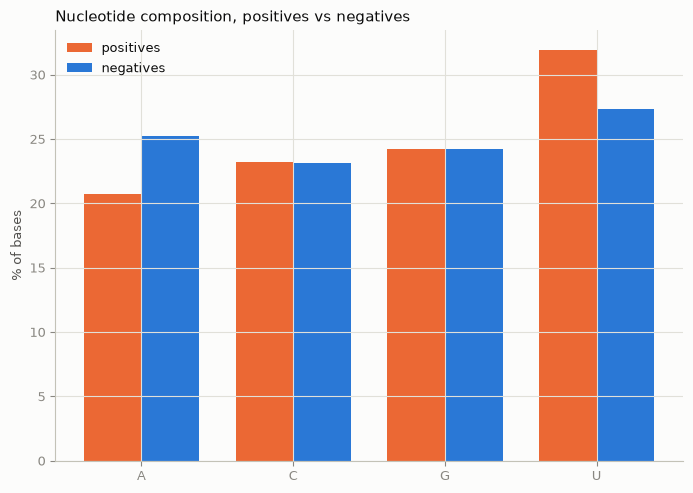

In [6]:
np_,nn_=Counter(),Counter()
for p in proteins:
    for s in data[p][data[p].label==1].seq_rna: np_.update(s)
    for s in data[p][data[p].label==0].seq_rna: nn_.update(s)
bases=list("ACGU"); tp,tn=sum(np_[b] for b in bases),sum(nn_[b] for b in bases); xp=np.arange(4); w=.38
fig,ax=plt.subplots(figsize=(7,5))
ax.bar(xp-w/2,[np_[b]/tp*100 for b in bases],w,color=ORANGE,label="positives")
ax.bar(xp+w/2,[nn_[b]/tn*100 for b in bases],w,color=BLUE,label="negatives")
ax.set_xticks(xp); ax.set_xticklabels(bases); ax.set_ylabel("% of bases"); ax.legend(frameon=False)
ax.set_title("Nucleotide composition, positives vs negatives",loc="left"); plt.tight_layout(); plt.show()

## 6 · Region composition
Which transcript regions do the peaks live in? Most of this panel is **intron-dominated** — which
is exactly why a splice-aware model has an edge (and see §9).

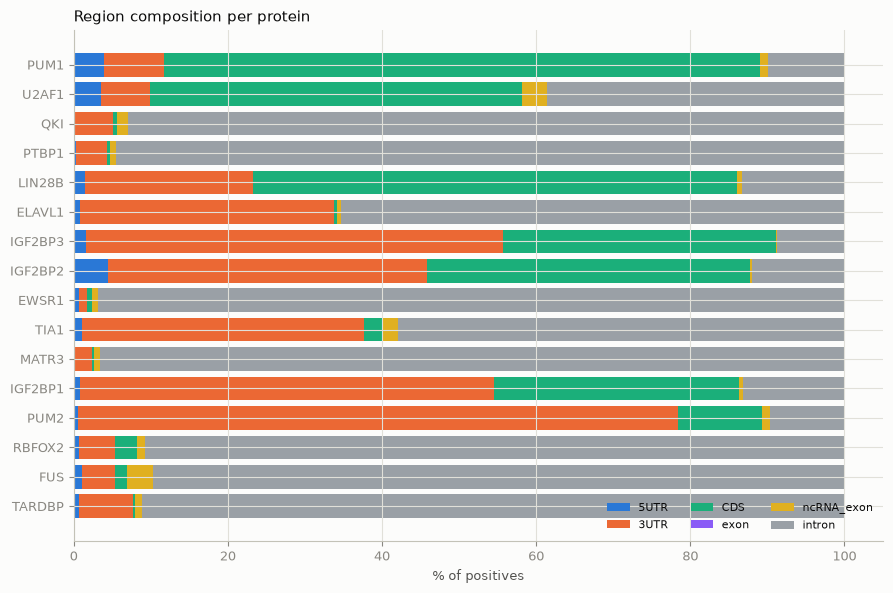

In [7]:
regions=["5UTR","3UTR","CDS","exon","ncRNA_exon","intron"]; cols=[BLUE,ORANGE,GREEN,PURPLE,GOLD,GREY]
rf={p:data[p][data[p].label==1].region.value_counts(normalize=True) for p in proteins}
fig,ax=plt.subplots(figsize=(9,6)); bottom=np.zeros(len(proteins))
for r,c in zip(regions,cols):
    v=np.array([rf[p].get(r,0)*100 for p in proteins]); ax.barh(proteins,v,left=bottom,color=c,label=r); bottom+=v
ax.set_xlabel("% of positives"); ax.legend(frameon=False,ncol=3,fontsize=8)
ax.set_title("Region composition per protein",loc="left"); plt.tight_layout(); plt.show()

## 7 · Raw eCLIP peak widths
Sanity on the raw signal — how wide are the called peaks before we force them to 101-nt windows?

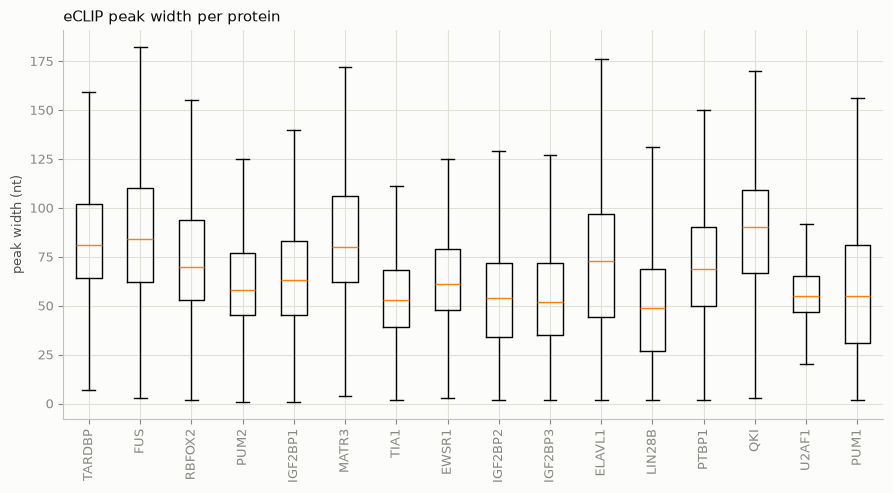

In [8]:
wdata,wl=[],[]
for p in proteins:
    try:
        w=[]
        with gzip.open(ENC/f"{p}.{acc[p]}.bed.gz","rt") as f:
            for line in f:
                c=line.split("\t"); w.append(int(c[2])-int(c[1]))
        wdata.append(w); wl.append(p)
    except Exception: pass
if wdata:
    fig,ax=plt.subplots(figsize=(9,5)); ax.boxplot(wdata,showfliers=False)
    ax.set_xticks(range(1,len(wl)+1)); ax.set_xticklabels(wl,rotation=90)
    ax.set_ylabel("peak width (nt)"); ax.set_title("eCLIP peak width per protein",loc="left")
    plt.tight_layout(); plt.show()
else: print("raw peaks not found (skipped)")

## 8 · Motif signal — is the biology there?
For each protein, the most enriched 6-mer in positives vs negatives (log2). `✓` = it matches the
known literature motif. Also the enrichment of the *known* motif directly (a fairer recovery check).

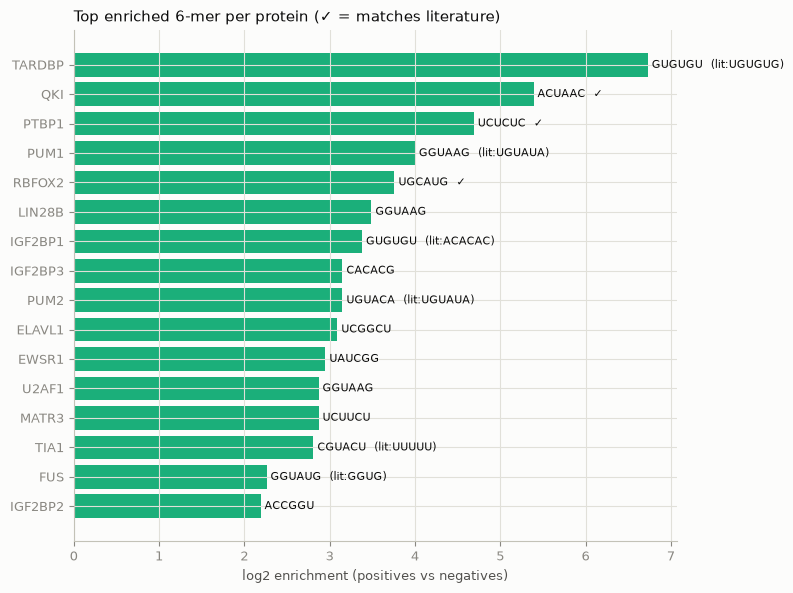

,protein,top_6mer,enrich,known,known_enrich,top5
0,IGF2BP2,ACCGGU,2.19,,NaN,"ACCGGU, GGUAAG, AGGUAA, UCCGGU, UCCGCG"
1,FUS,GGUAUG,2.26,GGUG,0.70,"GGUAUG, GUAUAG, AGGUAA, CAGGUA, UAGCGU"
2,TIA1,CGUACU,2.81,UUUUU,0.66,"CGUACU, CCGUCG, UUCGCG, UCCGAU, UUUCCG"
3,MATR3,UCUUCU,2.87,,NaN,"UCUUCU, UUCUUC, CUCUCU, CUUCUU, UCUCUC"
4,U2AF1,GGUAAG,2.87,,NaN,"GGUAAG, UUUUUU, UUUUCC, UUUUUC, UUCUUU"
5,EWSR1,UAUCGG,2.95,,NaN,"UAUCGG, AUCGGU, UUGGAU, UAAGGA, GUAUGU"
6,ELAVL1,UCGGCU,3.09,,NaN,"UCGGCU, CGCGAU, UCUCGG, AUCUCG, CGAUCU"
7,PUM2,UGUACA,3.15,UGUAUA,3.10,"UGUACA, UGUAUA, GUAUAU, GUAAAU, GUACAU"
8,IGF2BP3,CACACG,3.15,,NaN,"CACACG, AUUCAC, CAAUCA, CUAAUC, ACACUA"
9,IGF2BP1,GUGUGU,3.38,ACACAC,0.45,"GUGUGU, CGCGCG, UGUGUG, GCGCGC, CGCGUG"


In [9]:
rows=[]
for p in proteins:
    pos,neg=data[p][data[p].label==1],data[p][data[p].label==0]
    kp,kn=kmers(pos.seq_rna),kmers(neg.seq_rna); tp,tn=sum(kp.values()),sum(kn.values())
    enr={km:np.log2((cp/tp)/((kn.get(km,0)+1)/(tn+1))) for km,cp in kp.items() if cp>=30}
    best=max(enr,key=enr.get) if enr else "-"
    km_known=KNOWN.get(p,""); k=len(km_known)
    if km_known:
        cpk=sum(s.count(km_known) for s in pos.seq_rna); cnk=sum(s.count(km_known) for s in neg.seq_rna)
        tpk=sum(max(len(s)-k+1,0) for s in pos.seq_rna); tnk=sum(max(len(s)-k+1,0) for s in neg.seq_rna)
        known_enr=float(np.log2((cpk/tpk+1e-9)/((cnk+1)/(tnk+1))))
    else: known_enr=np.nan
    top5=", ".join(k for k,_ in sorted(enr.items(),key=lambda x:-x[1])[:5])
    rows.append(dict(protein=p,top_6mer=best,enrich=round(enr[best],2) if enr else 0,
                     known=km_known,known_enrich=round(known_enr,2) if known_enr==known_enr else np.nan,top5=top5))
MO=pd.DataFrame(rows).sort_values("enrich")
fig,ax=plt.subplots(figsize=(8,6)); ax.barh(MO.protein,MO.enrich,color=GREEN)
for i,(k6,kn) in enumerate(zip(MO.top_6mer,MO.known)):
    tag=k6+("  ✓" if kn and (kn in k6 or k6 in kn) else (f"  (lit:{kn})" if kn else ""))
    ax.text(MO.enrich.iloc[i],i," "+tag,va="center",fontsize=8)
ax.set_xlabel("log2 enrichment (positives vs negatives)")
ax.set_title("Top enriched 6-mer per protein (✓ = matches literature)",loc="left")
plt.tight_layout(); plt.show()
MO[["protein","top_6mer","enrich","known","known_enrich","top5"]].reset_index(drop=True)

## 9 · Where the motif sits — the splice-site confound ⚠️
If a peak marks a real binding site, its motif should peak near the **window centre** (dashed line).
Watch **PUM1** and **LIN28B**: their top 6-mer is `GGUAAG` — the **5′ splice-donor consensus**, not
their own motif — and it isn't centred, it spikes at fixed offsets. Part of "positive vs negative"
for intron-heavy proteins is *proximity to a splice site*. This is real biology (and why SpliceBERT
wins), but it's a confound — which is why we add the **splice-matched negative ablation** for
PUM1/LIN28B/U2AF1, with RBFOX2 (clean `UGCAUG` motif) as the control.

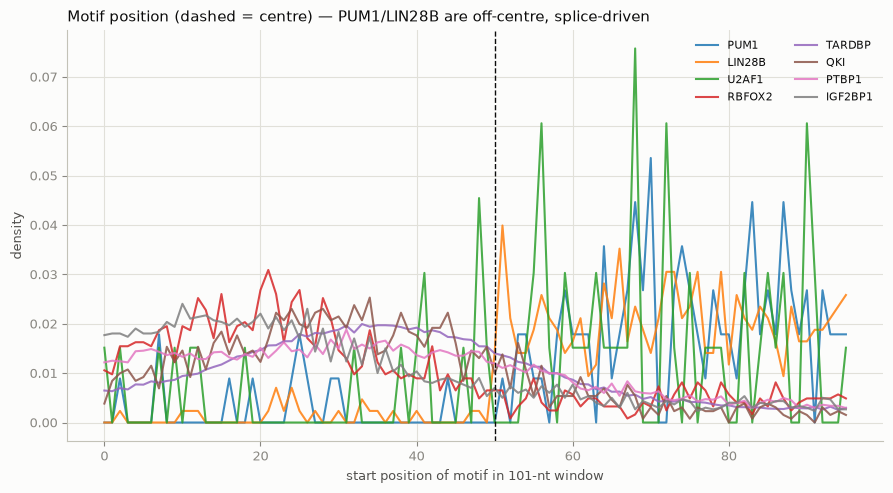

In [10]:
mp={}
for p in proteins:
    pos=data[p][data[p].label==1]
    kp=kmers(pos.seq_rna); best=max(kp,key=kp.get) if kp else None
    # re-derive the enrichment-best motif for consistency with §8
for p in proteins:
    pos=data[p][data[p].label==1]; neg=data[p][data[p].label==0]
    kp,kn=kmers(pos.seq_rna),kmers(neg.seq_rna); tp,tn=sum(kp.values()),sum(kn.values())
    enr={km:np.log2((cp/tp)/((kn.get(km,0)+1)/(tn+1))) for km,cp in kp.items() if cp>=30}
    if not enr: continue
    best=max(enr,key=enr.get); h=np.zeros(101-6+1)
    for s in pos.seq_rna:
        i=s.find(best)
        while i!=-1:
            if i<len(h): h[i]+=1
            i=s.find(best,i+1)
    if h.sum(): mp[p]=h/h.sum()
strong=sorted(mp, key=lambda q: -kmers(data[q][data[q].label==1].seq_rna).most_common(1)[0][1])
show=["PUM1","LIN28B","U2AF1","RBFOX2","TARDBP","QKI","PTBP1","IGF2BP1"]
fig,ax=plt.subplots(figsize=(9,5))
for p in show:
    if p in mp: ax.plot(np.arange(len(mp[p])),mp[p],lw=1.5,label=p,alpha=.85)
ax.axvline(50,color=INK,lw=1,ls="--")
ax.set_xlabel("start position of motif in 101-nt window"); ax.set_ylabel("density")
ax.legend(frameon=False,ncol=2,fontsize=8)
ax.set_title("Motif position (dashed = centre) — PUM1/LIN28B are off-centre, splice-driven",loc="left")
plt.tight_layout(); plt.show()

## 10 · Sequence complexity vs redundancy
Low-complexity windows (U-rich / homopolymer) and exact-duplicate windows. **ELAVL1** is 38%
low-complexity (AU-rich element binder); **zero duplicates** anywhere means no redundancy inflation.

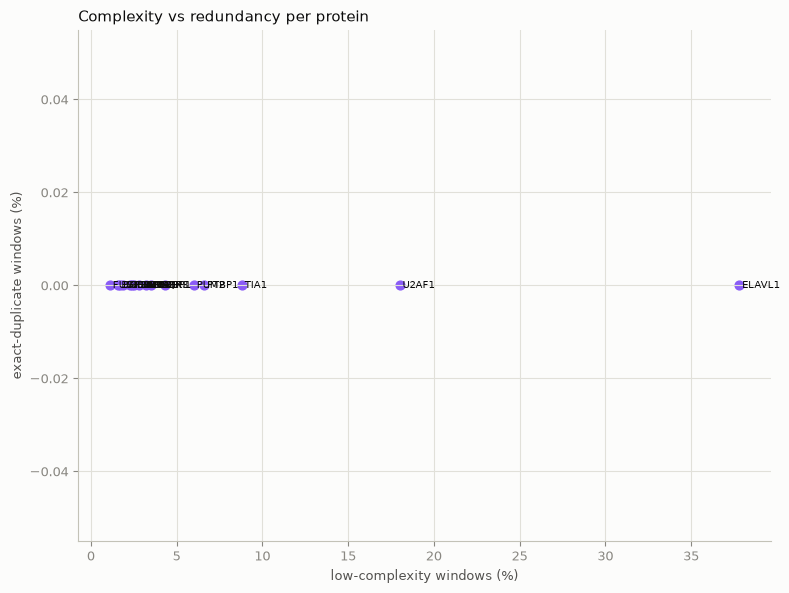

max duplicate %: 0.0


In [11]:
rows=[]
for p in proteins:
    pos=data[p][data[p].label==1]
    rows.append(dict(protein=p,low_complexity_pct=round(low_complexity_frac(pos.seq_rna)*100,1),
                     dup_pct=round((1-pos.seq_rna.nunique()/len(pos))*100,2)))
CR=pd.DataFrame(rows)
fig,ax=plt.subplots(figsize=(8,6)); ax.scatter(CR.low_complexity_pct,CR.dup_pct,s=40,color=PURPLE)
for _,r in CR.iterrows(): ax.text(r.low_complexity_pct,r.dup_pct," "+r.protein,fontsize=7,va="center")
ax.set_xlabel("low-complexity windows (%)"); ax.set_ylabel("exact-duplicate windows (%)")
ax.set_title("Complexity vs redundancy per protein",loc="left"); plt.tight_layout(); plt.show()
print("max duplicate %:", CR.dup_pct.max())

## 11 · Red-flag stress test & summary
Automated checks against every modelling assumption, plus a cross-split identical-sequence check
(repeat-driven leakage).

In [12]:
summ=[]
for p in proteins:
    pos,neg=data[p][data[p].label==1],data[p][data[p].label==0]
    summ.append(dict(protein=p,pairs=len(pos),train=sc[p]['train'],val=sc[p]['val'],test=sc[p]['test'],
        gc_gap=round(abs(pos.gc.mean()-neg.gc.mean()),3),
        low_complexity_pct=round(low_complexity_frac(pos.seq_rna)*100,1),
        dup_pct=round((1-pos.seq_rna.nunique()/len(pos))*100,2)))
SUM=pd.DataFrame(summ)

flags=[]
for _,r in SUM.iterrows():
    if r.val<MIN_EVAL_PAIRS: flags.append(f"{r.protein}: only {r.val} val pairs (<{MIN_EVAL_PAIRS})")
    if r.test<MIN_EVAL_PAIRS: flags.append(f"{r.protein}: only {r.test} test pairs (<{MIN_EVAL_PAIRS})")
    if r.gc_gap>0.03: flags.append(f"{r.protein}: GC gap {r.gc_gap}>0.03")
    if r.dup_pct>5: flags.append(f"{r.protein}: {r.dup_pct}% duplicate windows")
for p in proteins:
    seen=data[p].groupby("seq_rna").split2.nunique(); n=int((seen>1).sum())
    if n: flags.append(f"{p}: {n} sequences in >1 split (repeat leakage)")
print("RED FLAGS:", "\n  ⚠️ "+"\n  ⚠️ ".join(flags) if flags else "✅ none")
SUM.reset_index(drop=True)

RED FLAGS: ✅ none


,protein,pairs,train,val,test,gc_gap,low_complexity_pct,dup_pct
0,TARDBP,4589,2920,819,850,0.002,2.8,0.0
1,FUS,4464,2492,1264,708,0.008,1.1,0.0
2,RBFOX2,3519,2154,712,653,0.004,2.3,0.0
3,PUM2,5382,3594,559,1229,0.006,6.0,0.0
4,IGF2BP1,5706,3954,525,1227,0.003,3.2,0.0
5,MATR3,4868,3401,439,1028,0.002,3.5,0.0
6,TIA1,5883,3891,777,1215,0.000,8.8,0.0
7,EWSR1,8786,4744,2883,1159,0.006,1.6,0.0
8,IGF2BP2,3833,2530,630,673,0.010,1.7,0.0
9,IGF2BP3,2218,1373,288,557,0.004,1.9,0.0


## Findings → decisions

1. **Split is healthy.** 64.6 / 15.5 / 19.9 % train/val/test; every protein clears the 100-pair
   floor in val *and* test. U2AF1 (133 val) and QKI (187 val) are thin but usable — **accepted, not
   re-engineered**.
2. **Data is clean.** GC matched (gaps ≤0.010), no duplicate windows, no cross-split leakage.
3. **Motifs recovered** for the classic proteins (RBFOX2 `UGCAUG`, QKI `ACUAAC`, PTBP1 `UCUCUC`,
   TARDBP UG-repeat).
4. **Splice-site confound (the one that shifts the design).** For PUM1 / LIN28B / U2AF1 the strongest
   signal is the 5′ splice-donor, not the RBP motif → part of the task is "near a splice site."
   **Decision:** keep teammate-comparable negatives as the frozen primary set for all 16, **and** run
   a splice-distance-matched negative ablation on PUM1 / LIN28B / U2AF1 (RBFOX2 = clean-motif control)
   to *measure* how much of the AUROC is splice proximity.
5. **chr19 skews val** (gene-dense, in val) — documented, kept for teammate comparability.

**Verdict:** nothing defies the model-building plan; the one real consequence is the splice-matched
ablation on 4 proteins.